In [1]:
import pandas as pd

# Load the datsets
orders = pd.read_csv(r"C:\Users\Lenovo\OneDrive\DA\supply-chain-optimization\dataset_raw\orders_raw.csv")
routes = pd.read_csv(r"C:\Users\Lenovo\OneDrive\DA\supply-chain-optimization\dataset_raw\routes_raw.csv")
suppliers = pd.read_csv(r"C:\Users\Lenovo\OneDrive\DA\supply-chain-optimization\dataset_raw\suppliers_raw.csv")
carriers = pd.read_csv(r"C:\Users\Lenovo\OneDrive\DA\supply-chain-optimization\dataset_raw\carriers_raw.csv")

# Preview them
print("Orders:")
print(orders.head())

print("\nRoutes:")
print(routes.head())

print("\nSuppliers:")
print(suppliers.head())

print("\nCarriers:")
print(carriers.head())

Orders:
   order_id  order_date delivery_date promised_delivery_date  shipping_cost  \
0         1  2024-01-27    2024-02-01             2024-02-03        1771.53   
1         2  2024-03-24    2024-03-30             2024-03-27         786.73   
2         3  2024-08-08    2024-08-19             2024-08-18         644.44   
3         4  2024-11-26    2024-12-10             2024-12-05        1423.16   
4         5  2024-12-02    2024-12-08             2024-12-09        1826.73   

  delivery_status region  order_value  delay_days  route_id  supplier_id  \
0       Delivered   West      7425.10        -2.0       2.0          9.0   
1         Delayed  North      3310.21         3.0       1.0          8.0   
2         Delayed  North      2025.17         NaN      17.0          4.0   
3         Delayed  North      5314.42         5.0      16.0          7.0   
4       Delivered   West          NaN        -1.0      15.0         13.0   

   carrier_id  
0         1.0  
1         1.0  
2         9.

In [2]:
orders.info()
routes.info()
suppliers.info()
carriers.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                300 non-null    int64  
 1   order_date              300 non-null    str    
 2   delivery_date           287 non-null    str    
 3   promised_delivery_date  300 non-null    str    
 4   shipping_cost           282 non-null    float64
 5   delivery_status         300 non-null    str    
 6   region                  300 non-null    str    
 7   order_value             287 non-null    float64
 8   delay_days              267 non-null    float64
 9   route_id                288 non-null    float64
 10  supplier_id             295 non-null    float64
 11  carrier_id              281 non-null    float64
dtypes: float64(6), int64(1), str(5)
memory usage: 28.3 KB
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column   

In [3]:
orders.describe()

,order_id,shipping_cost,order_value,delay_days,route_id,supplier_id,carrier_id
count,300.000000,282.000000,287.000000,267.000000,288.000000,295.000000,281.000000
mean,150.500000,1296.467199,4183.455819,1.307116,10.250000,7.552542,5.626335
std,86.746758,671.622712,2691.667682,2.888151,5.688793,4.301137,2.681794
min,1.000000,106.450000,177.210000,-3.000000,1.000000,1.000000,1.000000
25%,75.750000,777.902500,2174.895000,-1.000000,5.000000,4.000000,4.000000
50%,150.500000,1328.260000,3637.680000,1.000000,10.000000,7.000000,6.000000
75%,225.250000,1835.615000,5925.255000,4.000000,15.000000,12.000000,8.000000
max,300.000000,2490.610000,12334.510000,6.000000,20.000000,15.000000,10.000000


In [4]:
orders.isnull().sum()

order_id                   0
order_date                 0
delivery_date             13
promised_delivery_date     0
shipping_cost             18
delivery_status            0
region                     0
order_value               13
delay_days                33
route_id                  12
supplier_id                5
carrier_id                19
dtype: int64

In [5]:
orders[['route_id','supplier_id','carrier_id']].isnull().sum()

route_id       12
supplier_id     5
carrier_id     19
dtype: int64

In [6]:
date_cols = ['order_date', 'delivery_date', 'promised_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

In [7]:
orders['delay_days_calc'] = (
    orders['delivery_date'] - orders['promised_delivery_date']
).dt.days

In [8]:
orders[['delay_days', 'delay_days_calc']].head()

,delay_days,delay_days_calc
0,-2.0,-2.0
1,3.0,3.0
2,NaN,1.0
3,5.0,5.0
4,-1.0,-1.0


In [9]:
orders['shipping_cost'].fillna(orders['shipping_cost'].median(), inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14376\2239025322.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  orders['shipping_cost'].fillna(orders['shipping_cost'].median(), inplace=True)


0      1771.53
1       786.73
2       644.44
3      1423.16
4      1826.73
        ...   
295    2356.07
296    2098.52
297    2130.53
298     397.42
299    1531.57
Name: shipping_cost, Length: 300, dtype: float64

In [10]:
orders['order_value'].fillna(orders['shipping_cost'] * 2, inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14376\1828489006.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  orders['order_value'].fillna(orders['shipping_cost'] * 2, inplace=True)


0       7425.10
1       3310.21
2       2025.17
3       5314.42
4       3653.46
         ...   
295     4528.51
296     7454.66
297    10035.76
298      777.52
299     2886.86
Name: order_value, Length: 300, dtype: float64

In [11]:
orders['route_id'].fillna(-1, inplace=True)
orders['supplier_id'].fillna(-1, inplace=True)
orders['carrier_id'].fillna(-1, inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14376\1328214582.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  orders['route_id'].fillna(-1, inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14376\1328214582.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment us

0      1.0
1      1.0
2      9.0
3      1.0
4      4.0
      ... 
295    8.0
296    7.0
297    1.0
298    8.0
299    2.0
Name: carrier_id, Length: 300, dtype: float64

In [12]:
orders['is_late'] = orders['delay_days_calc'] > 0

In [13]:
orders['high_value'] = orders['order_value'] > orders['order_value'].quantile(0.75)

In [14]:
orders['delivery_time'] = (
    orders['delivery_date'] - orders['order_date']
).dt.days

orders['cost_per_day'] = orders['shipping_cost'] / orders['delivery_time']

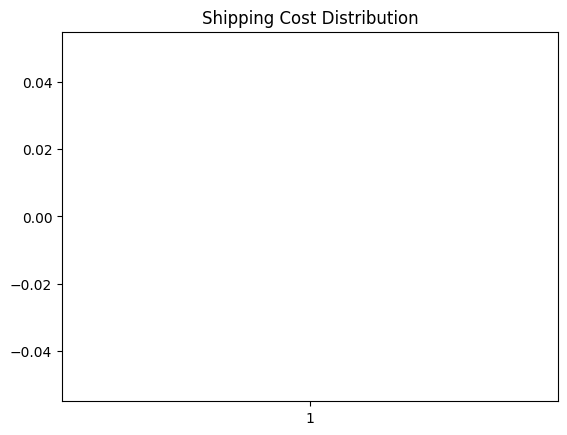

In [15]:
import matplotlib.pyplot as plt

plt.boxplot(orders['shipping_cost'])
plt.title("Shipping Cost Distribution")
plt.show()

In [17]:
print(orders['shipping_cost'].dtype)

float64


In [18]:
print(orders['shipping_cost'].isnull().sum())
print(len(orders))

18
300


In [19]:
print(orders['shipping_cost'].head(10))

0    1771.53
1     786.73
2     644.44
3    1423.16
4    1826.73
5    1115.46
6        NaN
7    1743.59
8    1254.24
9    1041.08
Name: shipping_cost, dtype: float64


In [20]:
orders['shipping_cost'].fillna(orders['shipping_cost'].median(), inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14376\2239025322.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  orders['shipping_cost'].fillna(orders['shipping_cost'].median(), inplace=True)


0      1771.53
1       786.73
2       644.44
3      1423.16
4      1826.73
        ...   
295    2356.07
296    2098.52
297    2130.53
298     397.42
299    1531.57
Name: shipping_cost, Length: 300, dtype: float64

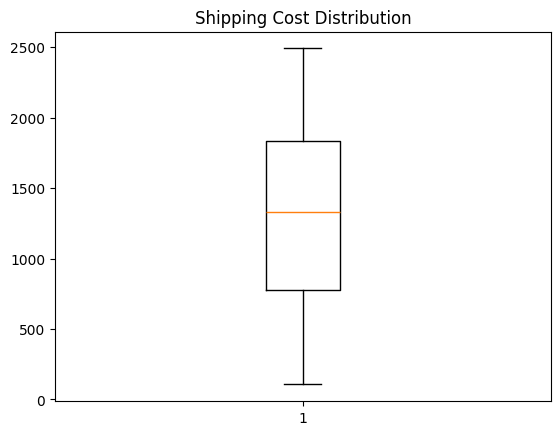

In [21]:
plt.boxplot(orders['shipping_cost'].dropna())
plt.title("Shipping Cost Distribution")
plt.show()

In [22]:
# On-time %
on_time = (orders['is_late'] == False).mean() * 100

# Avg cost
avg_cost = orders['shipping_cost'].mean()

# Avg delay
avg_delay = orders['delay_days_calc'].mean()

In [24]:
routes['distance'].fillna(routes['distance'].median(), inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14376\3746980384.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  routes['distance'].fillna(routes['distance'].median(), inplace=True)


0      949.0
1      758.5
2      729.8
3     1256.9
4      729.8
5      729.8
6     1273.8
7     1030.2
8      659.2
9      962.8
10     661.0
11     660.3
12     872.6
13     226.0
14     282.5
15     631.3
16     496.2
17     894.3
18     527.6
19     376.3
Name: distance, dtype: float64

In [25]:
routes['avg_delivery_time'].fillna(routes['avg_delivery_time'].median(), inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14376\397264028.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  routes['avg_delivery_time'].fillna(routes['avg_delivery_time'].median(), inplace=True)


0     23.4
1     13.9
2     19.2
3     28.1
4     13.4
5     14.9
6     23.1
7     22.6
8     15.7
9     20.5
10    13.4
11    12.9
12    18.5
13     4.2
14     6.3
15    12.0
16    11.2
17    21.6
18    11.8
19     7.0
Name: avg_delivery_time, dtype: float64

In [27]:
suppliers['cost_per_unit'].fillna(suppliers['cost_per_unit'].median(), inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14376\1536551385.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  suppliers['cost_per_unit'].fillna(suppliers['cost_per_unit'].median(), inplace=True)


0     255.23
1     139.85
2     316.59
3     323.40
4      79.27
5     484.53
6     187.08
7     357.90
8     104.92
9      65.47
10    166.45
11    190.27
12    296.02
13    486.31
14    472.77
Name: cost_per_unit, dtype: float64

In [29]:
carriers['cost_per_km'].fillna(carriers['cost_per_km'].median(), inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14376\2493388498.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  carriers['cost_per_km'].fillna(carriers['cost_per_km'].median(), inplace=True)


0     9.21
1     9.21
2     5.68
3    10.83
4    17.43
5     9.21
6     9.21
7     6.12
8    16.58
9     5.08
Name: cost_per_km, dtype: float64

In [30]:
carriers['on_time_rate'].fillna(carriers['on_time_rate'].mean(), inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14376\4229687815.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  carriers['on_time_rate'].fillna(carriers['on_time_rate'].mean(), inplace=True)


0    0.96
1    0.75
2    0.79
3    0.78
4    0.80
5    0.85
6    0.92
7    0.98
8    0.76
9    0.93
Name: on_time_rate, dtype: float64

In [31]:
df = orders.copy()

In [32]:
df = df.merge(routes, on='route_id', how='left')
df = df.merge(suppliers, on='supplier_id', how='left')
df = df.merge(carriers, on='carrier_id', how='left')

In [33]:
print("✅ Merge successful. Shape:", df.shape)

✅ Merge successful. Shape: (300, 26)


In [34]:
df.to_csv("clean_supply_chain_dataset.csv", index=False)